# Patch Generator — PYNQ Notebook

Streams a 32×32 RGB image to the patch generator IP and retrieves thermometer-encoded patches.

**Before running:** place the `lib/` folder from the testbench directory alongside this notebook.

**Input:** `data/pixel_input.txt` — one pixel per line, `C0 C1 C2` hex, top-row major.  
Generate this file on the host with `scripts/1_generate_pixel_input.py`.

**Output:** `data/patches_output/` — raw words (`tb_output.txt`), parsed patches (`patches.npz`),
and seven PNG visualisations.

| GPIO | Offset | Direction | Bits |
|------|--------|-----------|------|
| CH1 | `0x000` | Input  | bit 0 = `ps_request` |
| CH2 | `0x008` | Output | bits 4:1 = `ps_in[3:0]`, bit 0 = `ps_valid` |

In [82]:
import sys, os, time, threading
import numpy as np
from PIL import Image
from IPython.display import display

# ── lib/ path ────────────────────────────────────────────────────────────────
# Place lib/ from the testbench directory in the same folder as this notebook.
sys.path.insert(0, os.getcwd())

from lib.payload   import parse_patches_from_words, WORDS_PER_PATCH
from lib.visualize import (
    patch_to_image, patches_to_grid, reconstruct_image, encoded_image_to_pil
)
from lib.encoding  import thermometer_encode_array

from pynq import Overlay, allocate

# ── Constants ────────────────────────────────────────────────────────────────
IMG_SIZE    = 32
NUM_PIXELS  = IMG_SIZE * IMG_SIZE        # 1024
PS          = 3
NUM_PATCHES = (IMG_SIZE - PS + 1) ** 2   # 676
ENC_BITS    = 7

# ── Paths ────────────────────────────────────────────────────────────────────
PIX_FILE = 'data/pixel_input.txt'
OUT_DIR  = f'data/patches_output_{PS}x{PS}'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Hardware ─────────────────────────────────────────────────────────────────
ol   = Overlay('bitstreams/bd1.bit')
dma  = ol.axi_dma_0
gpio = ol.axi_gpio_0

GPIO_CH1 = 0x000   # input:  ps_request (1 bit)
GPIO_CH2 = 0x008   # output: ps_in[3:0] at bits 4:1, ps_valid at bit 0


# ps_in one-hot select — must match the case in patches_v5.vhd
PS_SELECT = {'3': 0b0001, '4': 0b0010, '5': 0b0100, '7': 0b1000}

def gpio_write(ps_in_bits, ps_valid):
    gpio.write(GPIO_CH2, int(ps_valid) | (ps_in_bits << 1))

def gpio_read_request():
    return gpio.read(GPIO_CH1) & 1

print(f'Peripherals: {list(ol.ip_dict.keys())}')
print(f'Output dir : {OUT_DIR}')
print(f'Patches    : {NUM_PATCHES}   Words/patch: {WORDS_PER_PATCH}')
print(f'DMA output : {NUM_PATCHES * WORDS_PER_PATCH * 4} bytes')
print('✓ Hardware initialised')

Peripherals: ['axi_dma_0', 'axi_gpio_0', 'processing_system7_0']
Output dir : data/patches_output_3x3
Patches    : 900   Words/patch: 34
DMA output : 122400 bytes
✓ Hardware initialised


In [83]:
# ── Load pixel_input.txt ─────────────────────────────────────────────────────
# Format: one pixel per line, "C0 C1 C2" hex, top-row major.
# C0=R  C1=G  C2=B  (matches axis_pixel_in.vhd word layout [23:16],[15:8],[7:0])
with open(PIX_FILE) as f:
    px_lines = [l.strip() for l in f
                if l.strip() and not l.startswith('#')]

assert len(px_lines) >= NUM_PIXELS, (
    f'Expected ≥{NUM_PIXELS} pixel lines in {PIX_FILE}, '
    f'got {len(px_lines)}.\n'
    'Run scripts/1_generate_pixel_input.py on the host first.'
)

# Pack into 32-bit words: {0x00, C0, C1, C2}
pixel_words = np.zeros(NUM_PIXELS, dtype=np.uint32)
for i, line in enumerate(px_lines[:NUM_PIXELS]):
    c0, c1, c2 = (int(h, 16) for h in line.split()[:3])
    pixel_words[i] = (c0 << 16) | (c1 << 8) | c2

# Reconstruct H×W×3 uint8 array (needed for encoded-image visualisation below)
raw_arr = np.column_stack([
    (pixel_words >> 16) & 0xFF,   # C0 -> R
    (pixel_words >>  8) & 0xFF,   # C1 -> G
     pixel_words        & 0xFF,   # C2 -> B
]).astype(np.uint8).reshape(IMG_SIZE, IMG_SIZE, 3)

print(f'Loaded {len(px_lines)} lines from {PIX_FILE}')
print(f'First word : 0x{pixel_words[0]:08x}')
print(f'Last  word : 0x{pixel_words[-1]:08x}')
print('✓ Pixel data loaded')

Loaded 1024 lines from data/pixel_input.txt
First word : 0x00647dcd
Last  word : 0x00d9dcff
✓ Pixel data loaded


In [84]:
# ── Allocate contiguous DMA buffers ──────────────────────────────────────────
in_buf  = allocate(shape=(NUM_PIXELS,),                    dtype=np.uint32)
out_buf = allocate(shape=(NUM_PATCHES * WORDS_PER_PATCH,), dtype=np.uint32)
in_buf[:] = pixel_words

print(f'in_buf:  {in_buf.nbytes:>7} bytes  @ 0x{in_buf.physical_address:08x}')
print(f'out_buf: {out_buf.nbytes:>7} bytes  @ 0x{out_buf.physical_address:08x}')
print('✓ Buffers allocated')

in_buf:     4096 bytes  @ 0x1584a000
out_buf:  122400 bytes  @ 0x15860000
✓ Buffers allocated


In [85]:
# ── PS handshake ─────────────────────────────────────────────────────────────
# Poll for ps_request, then send the patch-size one-hot code + ps_valid pulse.
HANDSHAKE_TIMEOUT = 2.0   # seconds

if gpio_read_request() == 0:
    print('Waiting for ps_request...')
    deadline = time.time() + HANDSHAKE_TIMEOUT
    while time.time() < deadline:
        if gpio_read_request():
            break
        time.sleep(0.001)
    else:
        print('⚠ Timeout: ps_request never asserted — continuing anyway')

print(f'✓ ps_request high — sending PS={PS}')
gpio_write(PS_SELECT[str(PS)], ps_valid=1)
time.sleep(0.005)
gpio_write(0, ps_valid=0)
time.sleep(0.05)

req = gpio_read_request()
status = '✓ cleared' if req == 0 else '⚠ still high'
print(f'ps_request after ack: {req}  ({status})')

✓ ps_request high — sending PS=3
ps_request after ack: 0  (✓ cleared)


In [86]:
# ── DMA transfer ─────────────────────────────────────────────────────────────
# S2MM (receive) is started before MM2S (send) so no leading beats are missed.
# s2mm_introut is wired to IRQ_F2P; mm2s_introut is not — poll mm2s instead.
DMA_TIMEOUT  = 10.0    # seconds before falling back to polling
POLL_PERIOD  = 0.005
POLL_TIMEOUT = 60.0    # total polling budget

def dma_wait(channel, label):
    """Interrupt wait with polling fallback."""
    done, err = threading.Event(), [None]
    def _wait():
        try:    channel.wait()
        except Exception as e: err[0] = e
        finally: done.set()
    threading.Thread(target=_wait, daemon=True).start()
    if done.wait(timeout=DMA_TIMEOUT):
        if err[0] is None:
            print(f'  {label}: ✓ interrupt'); return
        print(f'  {label}: wait() raised ({err[0]}) — polling')
    else:
        print(f'  {label}: interrupt timeout — polling')
    deadline = time.time() + POLL_TIMEOUT
    while time.time() < deadline:
        if channel.idle:
            print(f'  {label}: ✓ polling'); return
        time.sleep(POLL_PERIOD)
    print(f'  ⚠ {label}: never became idle — continuing anyway')

print('Starting DMA...')
dma.recvchannel.start()
dma.sendchannel.start()
dma.recvchannel.transfer(out_buf)   # S2MM — must be ready before MM2S fires
dma.sendchannel.transfer(in_buf)    # MM2S

t0 = time.time()

# MM2S: poll only (no interrupt)
print('  MM2S: polling...')
deadline = time.time() + POLL_TIMEOUT
while time.time() < deadline:
    if dma.sendchannel.idle:
        print('  MM2S: ✓ complete'); break
    time.sleep(POLL_PERIOD)
else:
    print('  ⚠ MM2S: timeout')

# S2MM: interrupt-driven
dma_wait(dma.recvchannel, 'S2MM')

print(f'✓ DMA complete in {time.time()-t0:.3f}s')

Starting DMA...
  MM2S: polling...
  MM2S: ✓ complete
  S2MM: ✓ interrupt
✓ DMA complete in 0.006s


In [87]:
# ── Output buffer sanity check ────────────────────────────────────────────────
nz = int(np.sum(out_buf != 0))
print(f'Non-zero words: {nz} / {len(out_buf)}  ({100*nz/len(out_buf):.1f}%)')
if nz == 0:
    print('✗ Buffer empty — no data received; check block design wiring')
else:
    print('First patch raw words:')
    for i, w in enumerate(out_buf[:WORDS_PER_PATCH]):
        print(f'  word {i:2d}: 0x{int(w):08x}')

Non-zero words: 30400 / 30600  (99.3%)
First patch raw words:
  word  0: 0x00000000
  word  1: 0x00000003
  word  2: 0x877e1c39
  word  3: 0xf00000ff
  word  4: 0xffffffff
  word  5: 0xffffffff
  word  6: 0xfff871e7
  word  7: 0xc3871e3c
  word  8: 0x387fffff
  word  9: 0xffffffff
  word 10: 0xffffffff
  word 11: 0x000408f1
  word 12: 0xe1c7871f
  word 13: 0xffffffff
  word 14: 0xffffffff
  word 15: 0xffffffff
  word 16: 0xffffffff
  word 17: 0xffffffff
  word 18: 0xffffffff
  word 19: 0xffffffff
  word 20: 0xffffffff
  word 21: 0xffffffff
  word 22: 0xffffffff
  word 23: 0xffffffff
  word 24: 0xffffffff
  word 25: 0xffffffff
  word 26: 0xffffffff
  word 27: 0xffffffff
  word 28: 0xffffffff
  word 29: 0xffffffff
  word 30: 0xffffffff
  word 31: 0xffffffff
  word 32: 0xffffffff
  word 33: 0xfffffffe


In [88]:
# ── Write raw words in testbench-compatible format ────────────────────────────
# Format is identical to the VHDL testbench's tb_output.txt, so you can copy
# this file back to the host and run scripts/2_parse_tb_output.py on it.
raw_out = os.path.join(OUT_DIR, 'tb_output.txt')
with open(raw_out, 'w') as f:
    f.write(f'# PYNQ hardware output (PS={PS})\n')
    for p in range(NUM_PATCHES):
        base = p * WORDS_PER_PATCH
        for w in range(WORDS_PER_PATCH):
            word  = int(out_buf[base + w])
            tlast = ' TLAST' if w == WORDS_PER_PATCH - 1 else ''
            f.write(f'PATCH {p} WORD {w} DATA {word:08X}{tlast}\n')
print(f'✓ Raw words written  -> {raw_out}')

# ── Parse directly from the DMA buffer (faster than re-reading the file) ─────
# lib/payload.py mirrors axis_patch_out.vhd exactly.
# Payload layout (1088 bits, word 0 = MSB):
#   [1087:1059] y_pos  [1058:1030] x_pos
#   pixel i (row=i//7, col=i%7): C0|C1|C2 at bits [1029-21i : 1009-21i]
patches = parse_patches_from_words(np.array(out_buf, dtype=np.uint32))
print(f'✓ Parsed {len(patches)} patches')

p0 = patches[0]
print(f'Patch 0  x={p0.x_index}  y={p0.y_index}')
print(f'  C0 top row : {p0.c0[0].tolist()}')
print(f'  C1 top row : {p0.c1[0].tolist()}')
print(f'  C2 top row : {p0.c2[0].tolist()}')

✓ Raw words written  -> data/patches_output_3x3/tb_output.txt
✓ Parsed 900 patches
Patch 0  x=0  y=0
  C0 top row : [7, 7, 0, 127, 127, 127, 127]
  C1 top row : [7, 7, 0, 127, 127, 127, 127]
  C2 top row : [63, 31, 1, 127, 127, 127, 127]


In [89]:
# ── Save parsed patches (.npz) ───────────────────────────────────────────────
# Can be loaded by scripts/3_visualize_patches.py on the host for
# full-resolution offline rendering without re-running the hardware.
npz_out = os.path.join(OUT_DIR, 'patches.npz')
np.savez(
    npz_out,
    word_index = np.array([p.word_index for p in patches]),
    x_pos_raw  = np.array([p.x_pos_raw  for p in patches]),
    y_pos_raw  = np.array([p.y_pos_raw  for p in patches]),
    x_index    = np.array([p.x_index    for p in patches]),
    y_index    = np.array([p.y_index    for p in patches]),
    c0         = np.stack([p.c0 for p in patches]),
    c1         = np.stack([p.c1 for p in patches]),
    c2         = np.stack([p.c2 for p in patches]),
)
print(f'✓ Patches saved  -> {npz_out}')

✓ Patches saved  -> data/patches_output_3x3/patches.npz


── Encoded input image ──
  saved encoded_image.png  (256x256)  [input after thermometer encoding (as-is)]


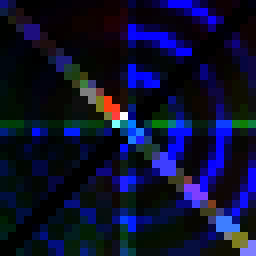


── Patch 0 (should match top-left 7x7 of input) ──
  saved 3x3_patch_0.png  (140x140)  [patch 0, inverse-decoded]


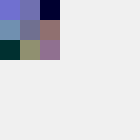

  saved 3x3_patch_0_encoded.png  (140x140)  [patch 0, as-is]


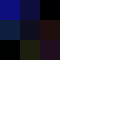


── Patch grid ──
  saved 3x3_patch_grid.png  (240x240)  [all patches at (x,y), inverse-decoded]


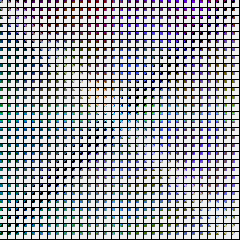

  saved 3x3_patch_grid_encoded.png  (240x240)  [all patches at (x,y), as-is]


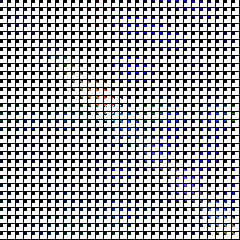


── Reconstruction from patches ──
  saved 3x3_patch_recon.png  (256x256)  [reconstruction, inverse-decoded]


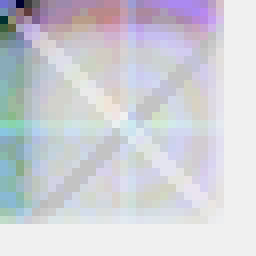

  saved 3x3_patch_recon_encoded.png  (256x256)  [reconstruction, as-is]


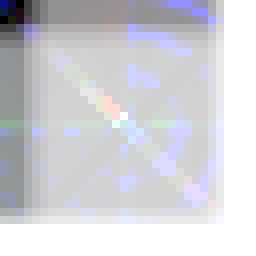


✓ All visualisations saved to data/patches_output_3x3/


In [90]:
# ── Visualise ─────────────────────────────────────────────────────────────────
# Two render modes (lib/visualize.py):
#   as_is=False  inverse-decoded: bin_idx -> centre of original 8-bit bin
#   as_is=True   raw scale:       thermometer value x 255/127
SCALE = 8   # upscale factor for full-image (32x32) outputs

def save_show(img, filename, label, scale=1):
    """Scale, save to OUT_DIR, and display inline."""
    if scale > 1:
        img = img.resize(
            (img.width * scale, img.height * scale), Image.NEAREST
        )
    path = os.path.join(OUT_DIR, filename)
    img.save(path)
    print(f'  saved {filename}  ({img.width}x{img.height})  [{label}]')
    display(img)

# ── 1. Encoded input image ────────────────────────────────────────────────────
# Shows the quantisation introduced by pixel_encoder.vhd before patching.
print('── Encoded input image ──')
enc_arr = thermometer_encode_array(raw_arr)
save_show(
    encoded_image_to_pil(enc_arr, as_is=True),
    'encoded_image.png',
    'input after thermometer encoding (as-is)',
    scale=SCALE
)

# ── 2. Patch 0 — canonical top-left check ────────────────────────────────────
# If the IP is correct, patch 0 must look like the top-left 7x7 of the input.
print('\n── Patch 0 (should match top-left 7x7 of input) ──')
save_show(patch_to_image(patches[0], scale=20),
          f'{PS}x{PS}_patch_0.png',          'patch 0, inverse-decoded')
save_show(patch_to_image(patches[0], scale=20, as_is=True),
          f'{PS}x{PS}_patch_0_encoded.png',  'patch 0, as-is')

# ── 3. Patch grid at decoded positions ───────────────────────────────────────
# Each patch cell is placed at (x_index, y_index) from its position registers.
print('\n── Patch grid ──')
save_show(patches_to_grid(patches, cell=8, use_position=True, as_is=False),
          f'{PS}x{PS}_patch_grid.png',         'all patches at (x,y), inverse-decoded')
save_show(patches_to_grid(patches, cell=8, use_position=True, as_is=True),
          f'{PS}x{PS}_patch_grid_encoded.png', 'all patches at (x,y), as-is')

# ── 4. Overlap-averaged reconstruction ───────────────────────────────────────
# Stitches overlapping patches into a single 32x32 image.
# Should closely resemble the original input (modulo thermometer quantisation).
print('\n── Reconstruction from patches ──')
save_show(reconstruct_image(patches, img_size=IMG_SIZE, as_is=False),
          f'{PS}x{PS}_patch_recon.png',         'reconstruction, inverse-decoded', scale=SCALE)
save_show(reconstruct_image(patches, img_size=IMG_SIZE, as_is=True),
          f'{PS}x{PS}_patch_recon_encoded.png', 'reconstruction, as-is',          scale=SCALE)

print(f'\n✓ All visualisations saved to {OUT_DIR}/')

In [91]:
print('=' * 52)
print(f'Image      {IMG_SIZE}x{IMG_SIZE} pixels  ({ENC_BITS}-bit thermometer)')
print(f'Patch      {PS}x{PS}  ->  {NUM_PATCHES} patches')
print(f'DMA recv   {NUM_PATCHES * WORDS_PER_PATCH * 4} bytes')
print(f'Output     {OUT_DIR}/')
for fn in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(os.path.join(OUT_DIR, fn))
    print(f'  {fn:<34} {sz:>9,} bytes')
print('=' * 52)

Image      32x32 pixels  (7-bit thermometer)
Patch      3x3  ->  900 patches
DMA recv   122400 bytes
Output     data/patches_output_3x3/
  3x3_patch_0.png                          468 bytes
  3x3_patch_0_encoded.png                  473 bytes
  3x3_patch_grid.png                     9,775 bytes
  3x3_patch_grid_encoded.png             8,087 bytes
  3x3_patch_recon.png                    3,086 bytes
  3x3_patch_recon_encoded.png            3,004 bytes
  encoded_image.png                      3,447 bytes
  patches.npz                          152,274 bytes
  tb_output.txt                        971,890 bytes
